# Predicting Selectivity for Sulfonamide-Derived Phosphoranyl Radical-Mediated Reactions

#### This notebook contains the reported MLR model for predicting B:A selectivity of sulfonamide-derived phosphoranyl radicals where product B is a hydrosulfonylation product arising from beta-scission, and product A is a hydroamination product arising from alpha-scission. This notebook includes the provision to predict selectivity for a new PC3-substituted phosphine, provided that the phosphine is present in the kraken database. 

##### For use of this notebook please cite the related manuscript: *insert reference*

##### To access the kraken database please see https://descriptor-libraries.molssi.org/kraken/

# 1. Imports

In [2]:
# stdlib
import re
import copy
import random
import itertools
import statistics
import multiprocessing

# data wrangling
import numpy as np
import pandas as pd
import statsmodels.api as sm

from scipy import stats
from sklearn import metrics
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import KFold

# molecule processing and display
from rdkit import Chem
from rdkit.Chem import Draw, AllChem, DataStructs
from rdkit.Chem import rdFingerprintGenerator
from IPython.display import display

# plotting
import seaborn as sns
import matplotlib.pyplot as plt
from jupyter_dash import JupyterDash
from dash import dcc, html, Input, Output
import plotly.graph_objects as go

# custom
from hotspot_classes import Hotspot
import hotspot_utils
import mlr_utils

# Set the number of processors to use for parallel processing
n_processors = max([1,multiprocessing.cpu_count()-2])

# 2. Read in the Experimental Data and Kraken Descriptors

### Import training set data

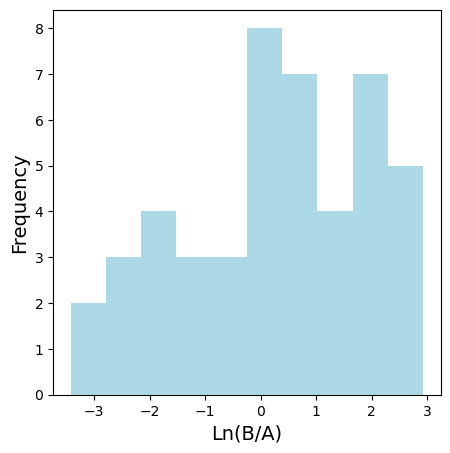

,Ln(B/A),vmin_vmin_boltz,vmin_r_boltz,fmo_e_homo_boltz,fmo_e_lumo_boltz,fmo_mu_boltz,fmo_eta_boltz,fmo_omega_boltz,somo_ra_boltz,somo_rc_boltz,...,sterimol_burB5_boltz,sterimol_burB5_min,sterimol_burB5_max,sterimol_burB5_delta,sterimol_burB5_vburminconf,sterimol_burL_boltz,sterimol_burL_min,sterimol_burL_max,sterimol_burL_delta,sterimol_burL_vburminconf
Kraken_ID,,,,,,,,,,,,,,,,,,,,,
11,-1.896495,-0.066835,1.796642,-0.220135,0.032067,-0.094034,0.252203,0.017531,0.104344,-0.423065,...,6.383627,6.090232,6.464182,0.373950,6.356046,7.242140,6.166027,7.428162,1.262135,7.055396
68,0.006120,-0.059782,1.802830,-0.228121,-0.022783,-0.125452,0.205338,0.038326,0.080182,-0.405563,...,6.354101,6.043273,6.493950,0.450677,6.137342,7.331124,7.181870,7.398709,0.216839,7.232378
162,1.210693,-0.053350,1.824003,-0.229748,-0.029067,-0.129408,0.200680,0.041724,0.064493,-0.401229,...,6.278431,6.047666,6.446225,0.398560,6.086300,7.194174,6.994299,7.347218,0.352918,7.347218
81,1.807327,-0.051019,1.840159,-0.230420,-0.027580,-0.129000,0.202840,0.041020,0.070970,-0.406070,...,6.060610,6.060610,6.060610,0.000000,6.060610,7.244836,7.244836,7.244836,0.000000,7.244836
17,2.140709,-0.048230,1.860160,-0.228390,-0.029490,-0.128940,0.198900,0.041794,0.060510,-0.394380,...,6.029300,6.029300,6.029300,0.000000,6.029300,6.914110,6.914110,6.914110,0.000000,6.914110
61,2.734682,-0.037637,1.860160,-0.238210,-0.043160,-0.140685,0.195050,0.050736,0.045820,-0.398440,...,6.051845,6.051845,6.051845,0.000000,6.051845,6.943428,6.943428,6.943428,0.000000,6.943428
62,0.545994,-0.056460,1.840158,-0.209950,-0.022226,-0.116088,0.187724,0.035894,0.061373,-0.352321,...,6.043525,6.032103,6.049074,0.016970,6.049074,6.958548,6.934667,6.976559,0.041892,6.934667
19,0.510724,-0.048827,1.857944,-0.230260,-0.029143,-0.129701,0.201117,0.041827,0.061312,-0.379549,...,6.931442,6.054706,7.098971,1.044265,6.054706,7.246557,7.210787,7.680655,0.469868,7.680655
212,1.784531,-0.050057,1.854444,-0.224140,-0.033457,-0.128798,0.190683,0.043508,0.049942,-0.370385,...,6.425083,6.086526,6.590770,0.504245,6.090326,7.071332,6.992673,8.167190,1.174517,8.167190


In [3]:
# This cell assumes that your spreadsheets are in .xlsx format and that there are no columns after the parameters
# or rows after the last reaction. Extra rows and columns before the data are fine and can be skipped with the
# vs_parameters_header_rows and vs_parameters_start_col variables.
# Check cell outputs before proceeding.

# --------------------------------------------------------------------------------------------------------------
# INPUTS
# --------------------------------------------------------------------------------------------------------------

# Leave these inputs unchanged to use the training data as reported in the manuscript. 

parameters_file = "experimental_data_and_kraken_descriptors" # Excel file to pull parameters from
parameters_sheet = "Train" # Sheet in the Excel file to pull parameters from
parameters_start_col = 9 # 0-indexed column number where the parameters start
parameters_y_label_col = 0  # 0-indexed column number where the ligand labels are
parameters_header_rows = 0 # Number of rows to skip when reading the parameters


response_file = "experimental_data_and_kraken_descriptors" # Excel file to pull responses from
response_sheet = "Train" # Sheet in the Excel file to pull responses from
response_col =  7 # 0-indexed column number for the responses
response_y_label_col = 0  # 0-indexed column number where the ligand labels are
response_header_rows = 0 # Number of rows to skip when reading the responses

RESPONSE_LABEL = "Ln(B/A)" # Name of your response variable. For selectivity, Ln(B/A) is used as the response label

# --------------------------------------------------------------------------------------------------------------
# EDIT ABOVE THIS LINE
# --------------------------------------------------------------------------------------------------------------

# Reading into dataframes
parameters_df = pd.read_excel("./InputData/" + parameters_file + ".xlsx",
                              parameters_sheet,
                              header = parameters_header_rows,
                              index_col = parameters_y_label_col,
                              )
response_df = pd.read_excel("./InputData/" + response_file + ".xlsx",
                            response_sheet,
                            header = response_header_rows,
                            index_col = response_y_label_col,
                            usecols = list(range(0, response_col + 1))
                            )


# Drop any columns before parameters_start_col that are not the index column
parameters_columns_to_keep = [col for col in range(0, len(parameters_df.columns)) if col >= parameters_start_col-1]
parameters_df = parameters_df.iloc[:,parameters_columns_to_keep]

# Combine the two dataframes into the master dataframe
response_df.drop(response_df.columns[0:response_col-1], axis = 'columns', inplace = True)
data_df = response_df.merge(parameters_df, left_index = True, right_index = True)
data_df.rename(columns = {data_df.columns.values[0]: RESPONSE_LABEL}, inplace = True) # Converts the output column name from whatever it is on the spreadsheet
data_df.dropna(inplace = True) # Remove any rows with blanks

# This converts all the data to numeric values
for column in data_df.columns:
    data_df[column] = pd.to_numeric(data_df[column], errors='coerce')

# Get a list of all the features
all_features = list(data_df.columns)
all_features.remove(RESPONSE_LABEL)

# Check for duplicate reaction labels or column names
error = False
if len(list(data_df.index)) != len(list(set(data_df.index))):
    print('THERE ARE DUPLICATE REACTION LABELS IN THE DATA. PLEASE CORRECT THIS IN YOUR SPREADSHEET.')
    error = True
if len(list(data_df.columns)) != len(list(set(data_df.columns))):
    print('THERE ARE DUPLICATE COLUMN NAMES IN THE DATA. PLEASE CORRECT THIS IN YOUR SPREADSHEET.')
    error = True

if not error:
    # Print out the data distribution of the response variable
    plt.figure(figsize=(5, 5))
    plt.hist(data_df[RESPONSE_LABEL], color='lightblue', bins=10)
    plt.xlabel(RESPONSE_LABEL, fontsize=14)
    plt.ylabel("Frequency", fontsize=14)
    plt.show()

data_df #display the dataframe

### External test set data

In [4]:
# This cell creates a data frame containing the external test set data. 
# This cell assumes that your spreadsheet is in .xlsx format and that there are no columns after the parameters
# or rows after the last reaction. Extra rows and columns before the data are fine and can be skipped with the
# vs_parameters_header_rows and vs_parameters_start_col variables.

# --------------------------------------------------------------------------------------------------------------
# INPUTS
# --------------------------------------------------------------------------------------------------------------

# Leave these options as is to model the reported data.

vs_parameters_file = "experimental_data_and_kraken_descriptors" # Excel file to pull parameters from
vs_parameters_sheet = "Test" # Sheet in the Excel file to pull parameters from
vs_parameters_start_col = 10   # 0-indexed column number where the parameters start
vs_parameters_y_label_col = 0  # 0-indexed column number where the ligand labels are
vs_parameters_header_rows = 0 # Number of rows to skip when reading the parameters. First row should be parameter names.

external_test_file = "experimental_data_and_kraken_descriptors" # Excel file to pull external test results from
external_test_sheet = "Test" # Sheet in the Excel file to pull external test results from
external_test_response_col = 8 # 0-indexed column number for the experimental output
external_test_y_label_col = 0  # 0-indexed column number where the ligand labels are
external_test_header_rows = 0 # Number of rows to skip when reading the responses

# --------------------------------------------------------------------------------------------------------------
# EDIT ABOVE THIS LINE
# --------------------------------------------------------------------------------------------------------------

# This code creates a dataframe with the ligand labels and the kraken features (parameters)

# Read into a dataframe
vs_parameters_df = pd.read_excel("./InputData/" + vs_parameters_file + ".xlsx",
                              vs_parameters_sheet,
                              header = vs_parameters_header_rows,
                              index_col = vs_parameters_y_label_col,
                              )

# Skip any columns that are not parameters
vs_parameters_df = vs_parameters_df.iloc[:,vs_parameters_start_col-1:]
vs_parameters_df.dropna(inplace=True)

# Check that all parameters from the original dataset are present and put them in the same order
try:
  vs_parameters_df = vs_parameters_df[all_features]
except KeyError:
  print('There are features in the main dataset that are not present in this parameter file.')
  print('If your model was built with scaled features, this will cause an error downstream.')

  # If any parameters are missing, at least remove all columns that are not in the original dataset
  columns_to_keep = [col for col in vs_parameters_df.columns if col in all_features]
  vs_parameters_df = vs_parameters_df[columns_to_keep]

# This code converts the above dataframe such that both the parameters and experimental response are combined

vs_response_df = pd.read_excel('./InputData/' + external_test_file + '.xlsx',
                              sheet_name=external_test_sheet,
                              header=external_test_header_rows,
                              index_col=external_test_y_label_col
                              )

# Drop all columns except the experimental output
vs_response_df = vs_response_df.iloc[:, [external_test_response_col-1]]
vs_response_df.columns = [RESPONSE_LABEL]

for column in vs_response_df.columns:
    vs_response_df[column] = pd.to_numeric(vs_response_df[column], errors='coerce')
vs_response_df.dropna(inplace = True)

vs_combined_df = pd.concat([vs_response_df, vs_parameters_df], axis=1, join='inner')

display(vs_combined_df)

,Ln(B/A),vmin_vmin_boltz,vmin_r_boltz,fmo_e_homo_boltz,fmo_e_lumo_boltz,fmo_mu_boltz,fmo_eta_boltz,fmo_omega_boltz,somo_ra_boltz,somo_rc_boltz,...,sterimol_burB5_boltz,sterimol_burB5_min,sterimol_burB5_max,sterimol_burB5_delta,sterimol_burB5_vburminconf,sterimol_burL_boltz,sterimol_burL_min,sterimol_burL_max,sterimol_burL_delta,sterimol_burL_vburminconf
Kraken_ID,,,,,,,,,,,,,,,,,,,,,
229,-0.364980,-0.060440,1.857882,-0.214683,-0.021896,-0.118290,0.192787,0.036297,0.065106,-0.366530,...,6.047537,6.045685,6.064030,0.018344,6.047703,7.078252,7.033797,7.194231,0.160434,7.140938
71,-1.708411,-0.052413,1.802083,-0.236110,-0.050230,-0.143170,0.185880,0.055137,0.054350,-0.420340,...,6.034538,6.034538,6.034538,0.000000,6.034538,7.062410,7.062410,7.062410,0.000000,7.062410
250,1.053133,-0.055436,1.871309,-0.210624,-0.048481,-0.129553,0.162144,0.051760,0.029696,-0.339061,...,7.202753,6.178854,7.578485,1.399631,6.801717,7.118055,7.009071,8.266453,1.257382,8.266453
266,2.060662,-0.047055,1.840847,-0.226968,-0.030453,-0.128710,0.196515,0.042150,0.060034,-0.391455,...,6.039518,6.039434,6.066694,0.027260,6.066694,6.963645,6.961778,7.574823,0.613045,7.574823


# 3. Train-Validation Split 

Training Set: [11, 68, 162, 81, 17, 61, 19, 212, 9, 5, 721, 236, 306, 253, 364, 284, 246, 249, 7, 31, 102, 126, 64, 25, 72, 1, 3, 53, 60, 90, 37, 280, 133, 368, 302, 157, 171]
Validation Set: [62, 4, 566, 42, 304, 10, 54, 50, 233]

Training Set size: 37
Validation Set size: 9

Training Set mean: 0.290
Validation Set mean: -0.135


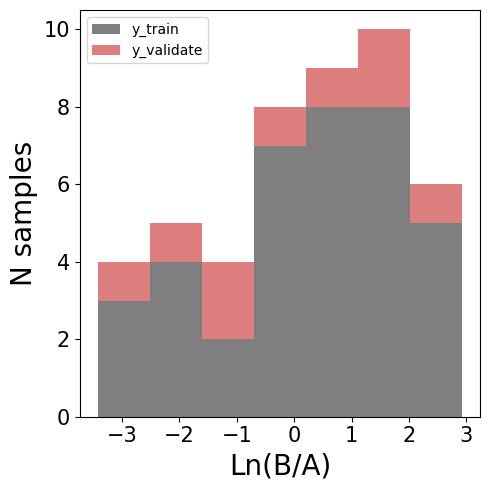

In [5]:
# This cell splits the training data into a train and validation set. 
# Reported model uses inputs as written: y_equidistant splitting and validation ratio of 0.2, with no held-out test set. 

# --------------------------------------------------------------------------------------------------------------
# INPUTS
# --------------------------------------------------------------------------------------------------------------


# Leave inputs as is to match reported modeling train-test split. 

# Split options are 'random', 'ks', 'y_equidistant', 'stratified', 'define', 'none'
# If you want to pull the train, validation, and test sets from only the subset of your data defined above, set use_filtering to True.

# Core options
split = "y_equidistant" # How to split the data.
validation_ratio = 0.2 # Ratio of validation set. Reported model: 0.2

# Test set options
use_test = False # Default is False.
test_ratio = 0.1 # Ratio of held out test data. 

# Some flags
use_filtering = False # Allows pre-filtering of data prior to train/validation split. Default is False.
use_scaling = True # Default is True. 

# Less common parameters
stratified_quantiles = 2 # Number of quantiles to split the data into for stratified sampling
defined_training_set =  [] # If you want to manually define the training set, put the list of points here
defined_validation_set =  [] # If you want to manually define the validation set, put the list of points here
defined_test_set = [] # If you want to manually define the test set, put the list of points here
randomstate = 48 # Random state for reproducibility. Default is 48.

# --------------------------------------------------------------------------------------------------------------
# EDIT ABOVE THIS LINE
# --------------------------------------------------------------------------------------------------------------

if use_filtering:
    training_set, validation_set, test_set = hotspot_utils.train_test_splits(data_df, split, validation_ratio, test_ratio, all_features, RESPONSE_LABEL, use_test,
                                                            defined_test_set=defined_test_set, defined_training_set=defined_training_set, defined_validation_set=defined_validation_set,
                                                            randomstate=randomstate, stratified_quantiles=stratified_quantiles, subset=points_to_keep)
else:
    training_set, validation_set, test_set = hotspot_utils.train_test_splits(data_df, split, validation_ratio, test_ratio, all_features, RESPONSE_LABEL, use_test,
                                                            defined_test_set=defined_test_set, defined_training_set=defined_training_set, defined_validation_set=defined_validation_set,
                                                            randomstate=randomstate, stratified_quantiles=stratified_quantiles)

if use_scaling:
    # Scales the parameters then puts them into modeling_data_df
    scaler = StandardScaler() # If you want to use a different scaler, change this line

    scaler.fit(data_df.loc[training_set, :])
    modeling_data = scaler.transform(data_df)
    modeling_data_df = pd.DataFrame(modeling_data, index = data_df.index, columns = data_df.columns)
    modeling_data_df[RESPONSE_LABEL] = data_df[RESPONSE_LABEL]
else:
    modeling_data_df = data_df

# For book-keeping purposes
if split == 'none':
    validation_ratio = 0
    test_ratio = 0

# 4. MLR Model With Experimental Data


================ MODEL EQUATION =================
    0.2898 +
   -1.5342 * fmo_e_homo_boltz
    1.1108 * nbo_bds_e_avg_boltz
    0.7593 * pyr_P_min
    0.7598 * vbur_vbur_boltz

================ TRAIN =================
R2   : 0.8892639899268869
MAE  : 0.4372409640601435
RMSE : 0.5372175654931434

================ VALIDATION =================
R2   : 0.9339486216789559
MAE  : 0.42866785362528403
RMSE : 0.48472245659531643

================ EXTERNAL TEST =================
R2   : 0.6333966012995758
MAE  : 0.8017863152396146
RMSE : 0.8637459716766526

================ K-FOLD CROSS-VALIDATION =================
Q2   : 0.8441594631189231
KFold R2 : 0.839607030772592 ± 0.014981949871330209

================ PARITY PLOT FOR TRAINED MLR MODEL =================


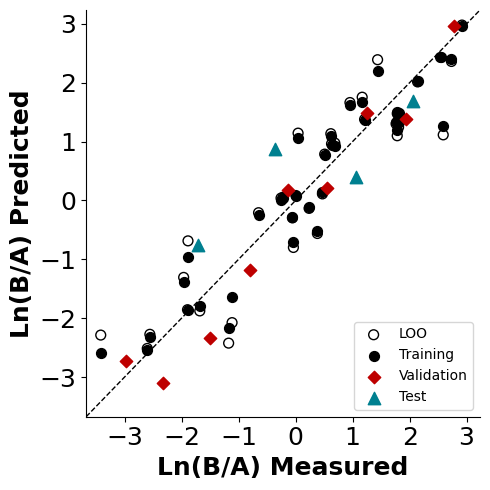

In [6]:
# This cell trains the MLR model with the experimental selectivity data and reports model metrics including:
# Train - training data as split above.
# Validation - validation set as split above.
# External test - as run and imported as a seperate dataframe.
# Cross-validation - k-fold cross-validation (training only).

# --------------------------------------------------------------------------------------------------------------
# NO INPUTS REQUIRED
# --------------------------------------------------------------------------------------------------------------

# =========================================================
# CONFIGURATION
# =========================================================

RESPONSE_LABEL = "Ln(B/A)"

features_selected = [
    "fmo_e_homo_boltz",
    "nbo_bds_e_avg_boltz",
    "pyr_P_min",
    "vbur_vbur_boltz"
]

features_selected = mlr_utils.process_features(features_selected, data_df)

# =========================================================
# SPLIT - AS ABOVE
# =========================================================

# =========================================================
# SCALE (FEATURE-ONLY FIT)
# =========================================================

scaler = StandardScaler()

# Fit selected features from training set
scaler.fit(data_df.loc[training_set, features_selected])

# Transform full dataset (only selected features)
scaled_df = data_df.copy()
scaled_df[features_selected] = scaler.transform(data_df[features_selected])

# =========================================================
# TRAIN / VALIDATION DATA
# =========================================================

x_train = scaled_df.loc[training_set, features_selected]
y_train = scaled_df.loc[training_set, RESPONSE_LABEL]

x_validate = scaled_df.loc[validation_set, features_selected]
y_validate = scaled_df.loc[validation_set, RESPONSE_LABEL]

# =========================================================
# MODEL TRAINING
# =========================================================

lr = LinearRegression().fit(x_train, y_train)

y_pred_train = lr.predict(x_train)
y_pred_val = lr.predict(x_validate)

# =========================================================
# EXTERNAL TEST SET
# =========================================================

vs_combined_df_scaled = vs_combined_df.copy()
vs_combined_df_scaled[features_selected] = scaler.transform(vs_combined_df[features_selected])

x_test = vs_combined_df_scaled[features_selected]
y_test = vs_combined_df_scaled[RESPONSE_LABEL]

y_pred_test = lr.predict(x_test)

# =========================================================
# METRICS
# =========================================================

def rmse(y, yhat):
    return np.sqrt(metrics.mean_squared_error(y, yhat))

# =========================================================
# MODEL EQUATION
# =========================================================

print("\n================ MODEL EQUATION =================")
print(f"{lr.intercept_:10.4f} +")
for i, f in enumerate(features_selected):
    print(f"{lr.coef_[i]:10.4f} * {f}")

# =========================================================
# TRAIN METRICS
# =========================================================

print("\n================ TRAIN =================")
print("R2   :", lr.score(x_train, y_train))
print("MAE  :", metrics.mean_absolute_error(y_train, y_pred_train))
print("RMSE :", rmse(y_train, y_pred_train))

# =========================================================
# VALIDATION METRICS
# =========================================================

print("\n================ VALIDATION =================")
print("R2   :", mlr_utils.external_r2(y_validate, y_pred_val, y_train))
print("MAE  :", metrics.mean_absolute_error(y_validate, y_pred_val))
print("RMSE :", rmse(y_validate, y_pred_val))

# =========================================================
# EXTERNAL TEST METRICS
# =========================================================

print("\n================ EXTERNAL TEST =================")
print("R2   :", mlr_utils.external_r2(y_test, y_pred_test, y_train))
print("MAE  :", metrics.mean_absolute_error(y_test, y_pred_test))
print("RMSE :", rmse(y_test, y_pred_test))

# =========================================================
# Q2 + K-FOLD (TRAIN ONLY)
# =========================================================

q2, loo_train = mlr_utils.calculate_q2(x_train, y_train)
kfold_scores = mlr_utils.repeated_k_fold(x_train, y_train, k=5, n=100)

print("\n================ K-FOLD CROSS-VALIDATION =================")
print("Q2   :", q2)
print("KFold R2 :", statistics.mean(kfold_scores),
      "±", statistics.stdev(kfold_scores))


# =========================================================
# PLOT (TRAIN + VAL + EXTERNAL)
# =========================================================


print("\n================ PARITY PLOT FOR TRAINED MLR MODEL =================")

mlr_utils.plot_MLR_model(
    y_train,
    y_pred_train,
    y_validate,
    y_pred_val,
    loo_train,
    y_predictions_test=y_pred_test,
    y_test=y_test,
    output_label=RESPONSE_LABEL,
    plot_xy=True)

### Nested Cross-Validation Metrics for the MLR Model

In [7]:
# This cell provides nested cross-validation metrics for the final MLR model. 
# Nested Cross-validation - nested cross-validation with training data only in the inner loop and training and validation data in the outer loop. 

#---------------------------------------------------------------------------------------------------------------
# NO INPUTS REQUIRED
# --------------------------------------------------------------------------------------------------------------

# If this cell fails to run, try changing the port number in the final line of code to a new port. 

# =========================================================
# CONFIGURATION
# =========================================================

RESPONSE_LABEL = "Ln(B/A)"

features_selected = [
    "fmo_e_homo_boltz",
    "nbo_bds_e_avg_boltz",
    "pyr_P_min",
    "vbur_vbur_boltz"
]

X = data_df[features_selected]
y = data_df[RESPONSE_LABEL]

X_train_full = X.loc[training_set]
y_train_full = y.loc[training_set]

X_val = X.loc[validation_set]
y_val = y.loc[validation_set]

# =========================================================
# INNER CV (on training set only)
# =========================================================

inner_cv = KFold(n_splits=5, shuffle=True, random_state=42)

inner_r2, inner_mae, inner_rmse, inner_q2 = [], [], [], []

for tr_idx, te_idx in inner_cv.split(X_train_full):

    X_tr, X_te = X_train_full.iloc[tr_idx], X_train_full.iloc[te_idx]
    y_tr, y_te = y_train_full.iloc[tr_idx], y_train_full.iloc[te_idx]

    scaler_in = StandardScaler()
    X_tr_s = scaler_in.fit_transform(X_tr)
    X_te_s = scaler_in.transform(X_te)

    model = LinearRegression()
    model.fit(X_tr_s, y_tr)

    preds = model.predict(X_te_s)

    inner_r2.append(r2_score(y_te, preds))
    inner_mae.append(mean_absolute_error(y_te, preds))
    inner_rmse.append(np.sqrt(mean_squared_error(y_te, preds)))

    ss_res = np.sum((y_te - preds) ** 2)
    ss_tot = np.sum((y_te - np.mean(y_tr)) ** 2)
    inner_q2.append(1 - ss_res / ss_tot)

# =========================================================
# OUTER CV (FULL DATA - TRUE CV)
# =========================================================

outer_cv = KFold(n_splits=5, shuffle=True, random_state=123)

outer_r2, outer_mae, outer_rmse, outer_q2 = [], [], [], []

for tr_idx, te_idx in outer_cv.split(X_train_full):

    X_tr, X_te = X.iloc[tr_idx], X_train_full.iloc[te_idx]
    y_tr, y_te = y.iloc[tr_idx], y_train_full.iloc[te_idx]

    scaler_out = StandardScaler()
    X_tr_s = scaler_out.fit_transform(X_tr)
    X_te_s = scaler_out.transform(X_te)

    model = LinearRegression()
    model.fit(X_tr_s, y_tr)

    preds = model.predict(X_te_s)

    outer_r2.append(r2_score(y_te, preds))
    outer_mae.append(mean_absolute_error(y_te, preds))
    outer_rmse.append(np.sqrt(mean_squared_error(y_te, preds)))

    ss_res = np.sum((y_te - preds) ** 2)
    ss_tot = np.sum((y_te - np.mean(y_tr)) ** 2)
    outer_q2.append(1 - ss_res / ss_tot)

# =========================================================
# FINAL MODEL (TRAINED ON FIXED SET THE SAME AS ABOVE CELL)
# =========================================================

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_full)

final_model = LinearRegression()
final_model.fit(X_train_scaled, y_train_full)

y_train_pred = final_model.predict(X_train_scaled)

y_val_pred = final_model.predict(scaler.transform(X_val))

# =========================================================
# METRICS
# =========================================================

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

# =========================================================
# PRINT RESULTS
# =========================================================

print("\n================ TRAIN =================")
print("R2   :", r2_score(y_train_full, y_train_pred))
print("MAE  :", mean_absolute_error(y_train_full, y_train_pred))
print("RMSE :", rmse(y_train_full, y_train_pred))

print("\n================ VALIDATION =================")
print("R2   :", r2_score(y_val, y_val_pred))
print("MAE  :", mean_absolute_error(y_val, y_val_pred))
print("RMSE :", rmse(y_val, y_val_pred))

print("\n================ INNER CV =================")
print(f"R2   : {np.mean(inner_r2):.3f} ± {np.std(inner_r2):.3f}")
print(f"MAE  : {np.mean(inner_mae):.3f} ± {np.std(inner_mae):.3f}")
print(f"RMSE : {np.mean(inner_rmse):.3f} ± {np.std(inner_rmse):.3f}")
print(f"Q2   : {np.mean(inner_q2):.3f} ± {np.std(inner_q2):.3f}")

print("\n================ OUTER CV =================")
print(f"R2   : {np.mean(outer_r2):.3f} ± {np.std(outer_r2):.3f}")
print(f"MAE  : {np.mean(outer_mae):.3f} ± {np.std(outer_mae):.3f}")
print(f"RMSE : {np.mean(outer_rmse):.3f} ± {np.std(outer_rmse):.3f}")
print(f"Q2   : {np.mean(outer_q2):.3f} ± {np.std(outer_q2):.3f}")


================ TRAIN =================
R2   : 0.8892639899268869
MAE  : 0.4372409640601435
RMSE : 0.5372175654931434

================ VALIDATION =================
R2   : 0.9304136903357041
MAE  : 0.42866785362528403
RMSE : 0.48472245659531643

================ INNER CV =================
R2   : 0.795 ± 0.134
MAE  : 0.496 ± 0.127
RMSE : 0.613 ± 0.114
Q2   : 0.799 ± 0.132

================ OUTER CV =================
R2   : 0.834 ± 0.070
MAE  : 0.463 ± 0.071
RMSE : 0.543 ± 0.087
Q2   : 0.887 ± 0.024


### Interactive plot of MLR model
#### click on the data point to view the structure of the phosphine


In [8]:
# This cell creates an interactive plot of the MLR model for viewing outputs with specific data points. 

# --------------------------------------------------------------------------------------------------------------
# NO INPUTS REQUIRED
# --------------------------------------------------------------------------------------------------------------

# =========================================================
# INTERACTIVE PLOT IMPORTS
# =========================================================

from io import BytesIO
import base64

# =========================================================
# PREPARE DATAFRAME
# =========================================================

filters = pd.read_csv("./InputData/phoss_filters.csv", index_col = 0)

# ---- Train / Val / Test ----
train_plot_df = pd.DataFrame({
    'x': y_train,
    'y': y_pred_train,
    'Type': 'Train',
    'Kraken_ID': y_train.index,
    'SMILES': filters.loc[y_train.index, 'smiles']
})

val_plot_df = pd.DataFrame({
    'x': y_validate,
    'y': y_pred_val,
    'Type': 'Validation',
    'Kraken_ID': y_validate.index,
    'SMILES': filters.loc[y_validate.index, 'smiles']
})

test_plot_df = pd.DataFrame({
    'x': y_test,
    'y': y_pred_test,
    'Type': 'Test',
    'Kraken_ID': y_test.index,
    'SMILES': filters.loc[y_test.index, 'smiles']
})

# Combine all plotting dataframes
plot_df = pd.concat([train_plot_df, val_plot_df, test_plot_df])


# =========================================================
# PREPARE FOR PLOTTING
# =========================================================

# Prep the dash app

app = JupyterDash(__name__)

app.layout = html.Div([
    html.Div([
        dcc.Graph(id='mlr_plot', style={'height': '80vh'})
    ], style={'width': '50%', 'display': 'inline-block'}),

    html.Div([
        html.H3("Molecule Viewer"),
        html.Img(id='mol_image', style={'maxWidth': '100%'}),
        html.Div(id='mol_info')
    ], style={'width': '28%', 'display': 'inline-block',
              'padding': '10px', 'border': '1px solid #ccc'})
])


# Plot Callback

@app.callback(
    Output('mlr_plot', 'figure'),
    Input('mlr_plot', 'id')  # dummy trigger
)
def update_plot(_):

    fig = go.Figure()

    color_map = {
        'Train': 'black',
        'Validation': 'steelblue',
        'Test': 'pink',
    }

    for t in ['Train', 'Validation', 'Test']:
        df_sub = plot_df[plot_df['Type'] == t]

        fig.add_trace(go.Scatter(
            x=df_sub['x'],
            y=df_sub['y'],
            mode='markers',
            name=t,
            marker=dict(
                color=color_map[t],
                size=6
            ),
            text=df_sub['Kraken_ID'],
            customdata=np.stack([
                df_sub['SMILES'],
                df_sub['y']
            ], axis=-1),
            hovertemplate=
                "Kraken ID: %{text}<br>" +
                "Predicted: %{y:.3f}<extra></extra>"
        ))

    # Add diagonal parity line
    lims = [
        plot_df['x'].min(),
        plot_df['x'].max()
    ]

    fig.add_shape(
        type='line',
        x0=lims[0], y0=lims[0],
        x1=lims[1], y1=lims[1],
        line=dict(dash='dash')
    )

    fig.update_layout(
        title="MLR Model With Experimental Results",
        xaxis_title="Experimental Ln(B/A)",
        yaxis_title="Predicted Ln(B/A)",
        clickmode='event+select'
    )

    return fig

# =========================================================
# INTRODUCE MOLECULE DISPLAY FEATURE
# =========================================================

@app.callback(
    Output('mol_image', 'src'),
    Output('mol_info', 'children'),
    Input('mlr_plot', 'clickData')
)
def display_molecule(clickData):

    if clickData is None:
        return "", "Click a point to see the molecule."

    kraken_id = clickData['points'][0]['text']
    smiles = plot_df.loc[plot_df['Kraken_ID'] == kraken_id, 'SMILES'].iloc[0]
    pred = clickData['points'][0]['y']

    mol = Chem.MolFromSmiles(smiles)
    img = Draw.MolToImage(mol, size=(300, 300))

    buf = BytesIO()
    img.save(buf, format="PNG")
    data = base64.b64encode(buf.getvalue()).decode()

    return (
        "data:image/png;base64," + data,
        f"Kraken_ID: {kraken_id} | Predicted Ln(B/A): {pred:.3f}"
    )

# =========================================================
# RUN PLOT
# =========================================================


app.run(mode='inline', port=8145)  # change the number in port if you get an error - it most likely means that port is already in use by another app or if you get--> TypeError: 'NoneType' object cannot be interpreted as an integer


# 5. Predict Selectivity for Phosphines in the Kraken Database 

### Load the Kraken data

In [9]:
# This cell loads the Kraken dataframe from the inputs directory. 

# --------------------------------------------------------------------------------------------------------------
# INPUTS
# --------------------------------------------------------------------------------------------------------------

view_df = True # Change to true to view the features dataframe. 

# --------------------------------------------------------------------------------------------------------------
# EDIT ABOVE THIS LINE
# --------------------------------------------------------------------------------------------------------------

# Load the kraken data from the provided csv file
kraken_data = pd.read_csv("./InputData/Kraken_descriptors_2025_LATEST-1.csv",
                         index_col = 0)

# Drop the last two columns to maintain only features and SMILES for each phosphine
features = kraken_data.iloc[:, :-4]

# View the kraken feature dataframe and the shape of the dataframe
if view_df == True:
    display(features)


,SMILES,vmin_vmin_boltz,vmin_r_boltz,fmo_e_homo_boltz,fmo_e_lumo_boltz,fmo_mu_boltz,fmo_eta_boltz,fmo_omega_boltz,somo_ra_boltz,somo_rc_boltz,...,sterimol_burB5_boltz,sterimol_burB5_min,sterimol_burB5_max,sterimol_burB5_delta,sterimol_burB5_vburminconf,sterimol_burL_boltz,sterimol_burL_min,sterimol_burL_max,sterimol_burL_delta,sterimol_burL_vburminconf
Kraken_ID,,,,,,,,,,,,,,,,,,,,,
1,CC(C)c1cc(C(C)C)c(-c2ccccc2P(C2CCCCC2)C2CCCCC2...,-0.061654,1.819048,-0.218243,-0.025112,-0.121678,0.193131,0.038336,0.059115,-0.363712,...,7.439480,6.306577,7.835474,1.528897,7.262693,7.291573,7.106519,8.238802,1.132283,7.735548
2,CN(C)c1cccc(N(C)C)c1-c1ccccc1P(C1CCCCC1)C1CCCCC1,-0.063670,1.784157,-0.206310,-0.023277,-0.114794,0.183033,0.036033,0.061658,-0.345264,...,6.572514,6.339063,7.850955,1.511892,6.407769,7.285463,6.908743,8.216943,1.308200,7.992698
3,COc1cccc(OC)c1-c1ccccc1P(C1CCCCC1)C1CCCCC1,-0.066303,1.798595,-0.213323,-0.016923,-0.115123,0.196400,0.033750,0.069846,-0.356952,...,7.156276,6.349086,7.287324,0.938238,7.021625,7.306643,7.025374,8.361404,1.336030,7.424874
4,CC(C)Oc1cccc(OC(C)C)c1-c1ccccc1P(C1CCCCC1)C1CC...,-0.067319,1.795292,-0.211571,-0.013802,-0.112687,0.197770,0.032124,0.070775,-0.349017,...,7.238774,6.369287,7.813010,1.443723,7.653520,7.338674,6.996319,8.333428,1.337110,7.483233
5,c1ccc(-c2ccccc2P(C2CCCCC2)C2CCCCC2)cc1,-0.061351,1.816461,-0.218842,-0.030145,-0.124494,0.188697,0.041069,0.060353,-0.376125,...,6.497622,6.092458,7.055260,0.962802,6.376705,7.370445,7.021018,8.155038,1.134020,8.086289
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2066,CCN(CC)p1oc2ccc3ccccc3c2c2c(ccc3ccccc32)o1,-0.033853,1.914518,-0.218212,-0.054844,-0.136528,0.163368,0.057049,0.030588,-0.357377,...,6.763499,6.756106,6.801929,0.045824,6.795094,7.158293,7.118344,7.632781,0.514437,7.632781
2067,C[C@H](c1ccccc1)N([C@H](C)c1ccccc1)p1oc2ccc3cc...,-0.030157,1.903323,-0.218620,-0.055066,-0.136843,0.163554,0.057249,0.026079,-0.330376,...,7.452606,6.762370,7.940839,1.178470,7.826542,7.296159,7.188915,8.338399,1.149484,7.188915
2068,CN(C)p1oc2ccc3c(c2c2c4c(ccc2o1)CCCC4)CCCC3,-0.038540,1.893225,-0.228080,-0.026966,-0.127523,0.201114,0.040431,0.061419,-0.372080,...,6.722689,6.712096,6.742565,0.030469,6.730741,7.137173,7.121478,7.153563,0.032085,7.124167


### Filter phosphines for prediction based on user input

In [10]:
# This cell sets up filters for the kraken dataframe based on user inputs. 
# Allows user to specify which filters to use on kraken phosphines prior to prediction.
# Check outputs for the number of phosphines in each catagory and to confirm selected filter options.

# --------------------------------------------------------------------------------------------------------------
# INPUTS
# --------------------------------------------------------------------------------------------------------------

commercial_availability = False # Set to True to see predictions for only commercially available phosphines.
PC3_space_only = True # Set to false to predict on all phosphines with PC3 substitution. We do not recommend changing to False as phosphines of 
                        # other oxidation states are out of the domain of the model.

# --------------------------------------------------------------------------------------------------------------
# EDIT ABOVE THIS LINE
# --------------------------------------------------------------------------------------------------------------

# Import the filters file which provides the data needed to filter kraken 
filters = pd.read_csv("./InputData/phoss_filters.csv", index_col = 0)

# Set up different subsets for prediction

pc3_phosphines = filters[filters['pat'] == 'pc3'].shape[0] # filters kraken to include only PC3 phosphines
print(f'number of PC3 phosphines in Kraken = {(pc3_phosphines)}') # PC3 referes to phosphines where phosphorus is connected to 3 carbon atoms 

commercial_phosphines = filters[filters['com'] == 1].shape[0] # filters kraken to include only commercial phosphines
print(f'number of commercial phosphines in Kraken space = {(commercial_phosphines)}')

commercial_pc3_phosphines = filters[(filters['pat'] == 'pc3') & (filters['com'] == 1)].shape[0] # filters to only commercial PC3-substituted phosphines
print(f'number of commercial PC3 phosphines = {(commercial_pc3_phosphines)}')

if commercial_availability is False and PC3_space_only is False: 
    print('Predicting all phosphines from kraken. Be aware phosphines without PC3 substitution are out of domain for this model.')

if commercial_availability is False and PC3_space_only is True: 
    print('Predicting all PC3 phosphines from kraken.')

if commercial_availability is True and PC3_space_only is False: 
    print('Predicting all commercial phosphines from kraken. Be aware phosphines without PC3 substitution are out of domain for this model.')

if commercial_availability is True and PC3_space_only is True: 
    print('Predicting all commercially available PC3 phosphines from kraken.')

number of PC3 phosphines in Kraken = 1019
number of commercial phosphines in Kraken space = 498
number of commercial PC3 phosphines = 322
Predicting all PC3 phosphines from kraken.


In [11]:
# This cell sets up filtering based on user inputs above.
# Verify the number of phosphines in the filtered category looks correct based on the outputs above.

# --------------------------------------------------------------------------------------------------------------
# INPUTS
# --------------------------------------------------------------------------------------------------------------

view_filter_df = False # Set to true to view the filters dataframe

# --------------------------------------------------------------------------------------------------------------
# EDIT ABOVE THIS LINE
# --------------------------------------------------------------------------------------------------------------

# For no filtering
if commercial_availability is False and PC3_space_only is False: 
    use_rows = features.index

# For commercial availability
if commercial_availability is True and PC3_space_only is False: 
    criterion1 = set(filters.loc[filters["com"] == 1].index)
    use_rows = sorted(criterion1)

# For PC3 only 
if commercial_availability is False and PC3_space_only is True: 
    criterion2 = set(filters.loc[filters["pat"] == "pc3"].index)
    use_rows = sorted(criterion2)

# For commercial availability any PC3 
if commercial_availability is True and PC3_space_only is True: 
    criterion1 = set(filters.loc[filters["com"] == 1].index)
    criterion2 = set(filters.loc[filters["pat"] == "pc3"].index)
    use_rows = sorted(criterion1 & criterion2)
                    
print(f"Keeping {len(use_rows)} compounds.")
filtered_filters = filters.loc[use_rows]

if view_filter_df == True: 
    display(filtered_filters)

Keeping 1019 compounds.


### Predict Ln(B/A) for New Phosphines from Kraken With Applied Filters

In [12]:
# This cell predicts selectivity (Ln(B/A)) for the subset of phosphines in kraken filtered dataframe above. 
# Please note selectivity predictions are based on a model system, and outputs should be taken as rankings rather than accurate
# predictions of magnitude when used to predict selectivity in cases other than the model system. 
# Please note that predictions of selectivity are not indicative of reactivity, and incompatible groups may be present in kraken. 

# --------------------------------------------------------------------------------------------------------------
# INPUTS
# --------------------------------------------------------------------------------------------------------------

save_predictions = False # Change to True to save predictions as a .csv
view_predictions_df = True # Change to False if you do not wish to display the predicted selectivity dataframe generated in this cell. 

# --------------------------------------------------------------------------------------------------------------
# EDIT ABOVE THIS LINE
# --------------------------------------------------------------------------------------------------------------

# Prep data for prediction of new phosphines

kraken_ids = filtered_filters.index.tolist()

kraken_subset = kraken_data.loc[kraken_ids]

model_features = [
    'fmo_e_homo_boltz', # HOMO energy
    'nbo_bds_e_avg_boltz', # Energy of the P-C antibonding orbital
    'pyr_P_min', # Pyramidalization
    'vbur_vbur_boltz' # Buried Volume
]

# restrict dataframe to relevant features
kraken_X = kraken_subset[model_features].dropna()

# scale the relevant features
kraken_X_scaled = pd.DataFrame(
    scaler.transform(kraken_X),
    index=kraken_X.index,
    columns=kraken_X.columns
)

kraken_X_scaled
# ---------------------------
# PREDICT Ln(B/A)
# ---------------------------
kraken_pred = lr.predict(kraken_X_scaled)

# ---------------------------
# FINAL OUTPUT TABLE/dataframe (USE THIS FOR PLOTTING)
# ---------------------------
kraken_pred_df = pd.DataFrame({
    "Kraken_ID": kraken_X.index,
    "Predicted": kraken_pred
})

kraken_pred_df["SMILES"] = kraken_subset.loc[kraken_X.index, "SMILES"].values

# Save the predictions
if save_predictions is True: 
    kraken_pred_df.to_csv('kraken_predictions-meow.csv', index=False)

# View the dataframe for predictions 
if view_predictions_df == True:
    display(kraken_pred_df)


,Kraken_ID,Predicted,SMILES
0,1,0.012237,CC(C)c1cc(C(C)C)c(-c2ccccc2P(C2CCCCC2)C2CCCCC2...
1,2,-0.644563,CN(C)c1cccc(N(C)C)c1-c1ccccc1P(C1CCCCC1)C1CCCCC1
2,3,-0.279456,COc1cccc(OC)c1-c1ccccc1P(C1CCCCC1)C1CCCCC1
3,4,0.172146,CC(C)Oc1cccc(OC(C)C)c1-c1ccccc1P(C1CCCCC1)C1CC...
4,5,-0.518498,c1ccc(-c2ccccc2P(C2CCCCC2)C2CCCCC2)cc1
...,...,...,...
1014,1902,-1.810208,c1ccc(P(C2CCCCC2)C2CCCCC2)c(-c2c(-c3c4ccccc4cc...
1015,1903,0.971355,COc1cccc(OC)c1-c1ccccc1-p1c(C)c(C)c(C)c1C
1016,1904,2.206999,COc1cccc(OC)c1-c1ccccc1-p1c2ccccc2c2ccccc21
1017,1906,-4.306169,c1ccc(C(P(C2CCCCC2)C2CCCCC2)=P(C2CCCCC2)(C2CCC...


### Obtain predictions for most selective phosphines

In [13]:
# This cell will provide a dataframe and list of kraken IDs for the most n selective phosphines for either A-selectivity or B-selectivity. 
# Please note selectivity predictions are based on a model system, and outputs should be taken as rankings rather than accurate
# predictions of magnitude when used to predict selectivity in cases other than the model system. 
# Please note that predictions of selectivity are not indicative of reactivity, and incompatible groups may be present in kraken. 

# --------------------------------------------------------------------------------------------------------------
# INPUTS
# --------------------------------------------------------------------------------------------------------------

selectivity_for = 'B' # Input 'A' for most A-selective and 'B' for most B-selective. 
top_prediction = 10 # Input the number of top predictions you would like to obtain. Default is top 10. 

# --------------------------------------------------------------------------------------------------------------
# EDIT ABOVE THIS LINE
# --------------------------------------------------------------------------------------------------------------

if selectivity_for == 'A': 
    sorted_A = kraken_pred_df.sort_values(by='Predicted', ascending=True)
    top_selectivity_df = sorted_A.head(top_prediction)
    top_selectivity_ids = top_selectivity_df['Kraken_ID'].to_list()

if selectivity_for == 'B': 
    sorted_B = kraken_pred_df.sort_values(by='Predicted', ascending=False)
    top_selectivity_df = sorted_B.head(top_prediction)
    top_selectivity_ids = top_selectivity_df['Kraken_ID'].to_list()

top_selectivity_df = top_selectivity_df.copy().set_index('Kraken_ID')

print(f'Kraken IDs for phosphines predicted to be most {selectivity_for}-selective: {top_selectivity_ids}')
top_selectivity_df

Kraken IDs for phosphines predicted to be most B-selective: [1835, 1591, 958, 412, 232, 1711, 1812, 1236, 1235, 508]


,Predicted,SMILES
Kraken_ID,,
1835,10.762896,FC(F)(F)C#CP(C#CC(F)(F)F)C#CC(F)(F)F
1591,9.084019,N#CP(C#N)c1ccccc1
958,6.467150,C=CP(C(F)(F)F)C(F)(F)F
412,6.009082,FC(F)(F)P(C(F)(F)F)C(F)(F)F
232,5.489055,FC(F)(F)c1cc(P(c2cc(C(F)(F)F)cc(C(F)(F)F)c2)c2...
1711,5.479534,CP(C)C#N
1812,5.335117,Fc1c(F)c(C(F)(F)F)c(F)c(F)c1P(c1c(F)c(F)c(C(F)...
1236,5.269524,FC(F)(F)c1ccc(P(c2ccc(C(F)(F)F)cc2Cc2ccccc2)c2...
1235,4.929339,FC(F)(F)Oc1ccc(P(c2ccc(OC(F)(F)F)cc2Cc2ccccc2)...


### View chemical structures of the top n selective phosphines predicted above

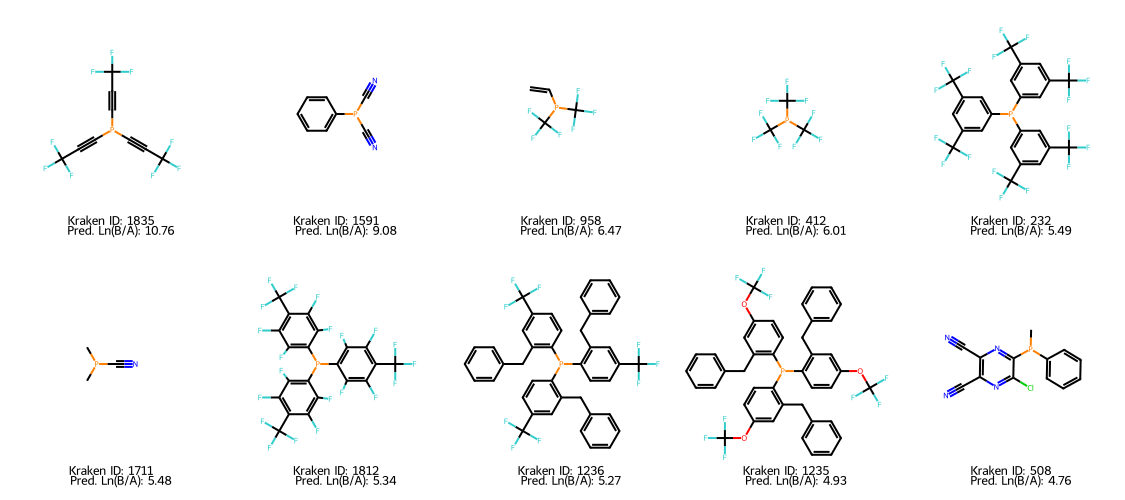

In [14]:
# This cell displays the top n selective phosphine predicted above as chemical structures 

# --------------------------------------------------------------------------------------------------------------
# NO INPUTS REQUIRED
# --------------------------------------------------------------------------------------------------------------

# View the most selective phosphines as molecular structures.

molobs1 = [Chem.MolFromSmiles(i) for i in top_selectivity_df['SMILES']]
legends= []

for id in top_selectivity_df.index:
    legend = f"""Kraken ID: {id} 
    Pred. Ln(B/A): {top_selectivity_df.loc[id, 'Predicted']:.2f}"""
    legends.append(legend)

# legends = [f"Cluster: {k}, ID: {v}" for k,v in data_df.loc[data_set_ids][cluster], (data_set_ids)]
img_src = Draw.MolsToGridImage(molobs1, subImgSize=(225,250), molsPerRow=4,
                                  legends = legends)
Draw.MolsToGridImage(molobs1, subImgSize=(225,250), molsPerRow=5,
                                  legends = legends)

# 6. Predict Selectivity for a Specific Phosphine

#### Provide EITHER smiles OR kraken ID of a phosphine for which you want to predict Ln(B/A)

In [15]:
# This cell will provide selectivity predictions for a phosphine or list of phosphines provided either the kraken ID or SMILES.
# Check outputs to confirm the entered phosphine matches the expected structure. 

# --------------------------------------------------------------------------------------------------------------
# INPUTS
# --------------------------------------------------------------------------------------------------------------

# Choose identification method

smiles_or_id = 'ID' # 'SMILES' or 'ID'. Input 'SMILES' to use smiles string for prediction. Input 'ID' to use kraken ID for prediction

# Provide phosphine identification as SMILES string or kraken ID

user_smiles_list = [] # input smiles here.

# OR

user_kraken_ids = [] # input kraken ID
    
# Provide similarity threshold to predict similar phosphines below. 

SIM_THRESHOLD = 0.4 # Tanimoto similarity threshold for suggesting similar Kraken compounds to user input smiles that is not in Kraken currently

# --------------------------------------------------------------------------------------------------------------
# EDIT ABOVE THIS LINE
# --------------------------------------------------------------------------------------------------------------

smiles_list = []

# Convert ID input to smiles string
if smiles_or_id == 'ID':
    for id in user_kraken_ids: 
        if id in kraken_pred_df['Kraken_ID']:
            smile = kraken_pred_df.loc[kraken_pred_df['Kraken_ID'] == id, 'SMILES'].values[0]
            smiles_list.append(smile)
        elif id in kraken_data.index.tolist():
            print(f'Phosphine {id} is not in your predictions but is in kraken. Please adjust your filters to include this phosphine class.')
        else: 
            print(f'{id} is not a valid phosphine in kraken. Please check your ID number.')
        
# Make smiles list from smiles input 
if smiles_or_id == 'SMILES':
    smiles_list = user_smiles_list

# Visualize the structure of the provided SMILES
for smiles in smiles_list:  # Loop through all smiles
    mol = Chem.MolFromSmiles(smiles)
    img = Draw.MolToImage(mol, size=(300, 300))
    display(img)  # Display the image in the notebook

### Predict the selectivity if the phosphine is in Kraken

In [16]:
# This cell will report the predicted selectivity for any phosphine (in the kraken database) selected by the user. 
# See cells above for input entry.
# If filters have been applied to predictions, some suggested phosphines may not have predicted values for selectivity. Adjust your filtering above. 
# Please note - predictions will be based on the subset of phosphines filtered above. Please adjust your filters if your phosphine is in Kraken. 

# --------------------------------------------------------------------------------------------------------------
# NO INPUTS REQUIRED
# --------------------------------------------------------------------------------------------------------------

# =========================================================
# PRECOMPUTE KRAKEN DATA
# =========================================================

def canonicalize(smiles):
    mol = Chem.MolFromSmiles(smiles)
    return Chem.MolToSmiles(mol) if mol else None

if "canonical_smiles" not in kraken_data.columns:
    kraken_data["canonical_smiles"] = kraken_data["SMILES"].apply(canonicalize)

# =========================================================
# IF USING KRAKEN ID
# =========================================================

pred_map = dict(zip(kraken_pred_df['Kraken_ID'], kraken_pred_df['Predicted']))

if smiles_or_id == 'ID':
    for id in user_kraken_ids:
        if id in kraken_pred_df['Kraken_ID']:
            prediction = pred_map.get(id, float('nan'))
            print(f'Phosphine {id} is in the kraken database. The predicted Ln(B/A) is {prediction:.2f}')
        elif id in kraken_data.index.tolist(): 
            print('This phosphines is not in your predictions but is in kraken. Please adjust your filters to include this phosphine class.')
        else: 
            print('The kraken ID entered is not a valid phosphine in kraken. Please check your ID number.')

# =========================================================
# IF USING SMILES
# =========================================================

if smiles_or_id == 'SMILES': 

    for smile in user_smiles_list:

        mol = Chem.MolFromSmiles(smile)
        if mol is None:
            print(f" Invalid SMILES: {smile}")
            continue
    
        canon = Chem.MolToSmiles(mol)
    
        print("\n==============================")
        print(f"Input SMILES: {smile}")

    # ------------------ EXACT MATCH ------------------
        exact = kraken_data[kraken_data["canonical_smiles"] == canon]
        user_results = []
        
        if len(exact) > 0:
            print(" Exact match found in Kraken")
        
            X_new = exact[model_features].dropna()
            preds = lr.predict(scaler.transform(X_new))
        
            df_exact = pd.DataFrame({
                "x": preds,
                "y": preds,
                "Type": "User_Input",
                "Kraken_ID": X_new.index,
                "SMILES": exact.loc[X_new.index, "SMILES"]
            })
        
            user_results.append(df_exact)
        
            #  SHOW MATCHED MOLECULE(S)
            mols = [Chem.MolFromSmiles(s) for s in df_exact["SMILES"]]
            legends = [f"{idx}" for idx in df_exact["Kraken_ID"]]
        
            display(Draw.MolsToGridImage(
                mols,
                molsPerRow=4,
                subImgSize=(200,200),
                legends=legends
            ))
        
            pred_map = dict(zip(kraken_pred_df['Kraken_ID'], kraken_pred_df['Predicted']))
        
            for idx in df_exact['Kraken_ID']:
                prediction = pred_map.get(idx, float('nan'))
                print(f'Phosphine {idx} is in the kraken database. The predicted Ln(B/A) is {prediction:.2f}')
        
        else: 
             print('The phosphine you entered is not in Kraken. Please proceed to the next section to predict selectivity for similar structures.')



### Predict selectivity for similar phosphines in the kraken database

In [17]:
# This cell takes a SMILES string as inputed above and predicts phosphines in the kraken database based on Tanimoto similarity.
# View the output structures and predicted selectivities below.

#This cell will run for SMILES inputs in the SMILES list above even if ID is called. Please ensure the correct SMILES input

# --------------------------------------------------------------------------------------------------------------
# NO INPUTS REQUIRED
# --------------------------------------------------------------------------------------------------------------

from io import BytesIO
import base64

# =========================================================
# PRECOMPUTE KRAKEN DATA
# =========================================================

if "canonical_smiles" not in kraken_data.columns:
    kraken_data["canonical_smiles"] = kraken_data["SMILES"].apply(canonicalize)

fpgen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)

if "fp" not in kraken_data.columns:
    def get_fp(smiles):
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            return None
        return fpgen.GetFingerprint(mol)

    kraken_data["fp"] = kraken_data["SMILES"].apply(get_fp)

# =========================================================
# PROCESS USER INPUT
# =========================================================

# Define the predictions

pred_map = dict(zip(kraken_pred_df['Kraken_ID'], kraken_pred_df['Predicted']))

# ---- SMILES ----
for smile in user_smiles_list:

    mol = Chem.MolFromSmiles(smile)
    if mol is None:
        print(f" Invalid SMILES: {smile}")
        continue

    canon = Chem.MolToSmiles(mol)
    fp = fpgen.GetFingerprint(mol)

    print("\n==============================")
    print(f" Input SMILES: {smile}")

    # 👉 SHOW INPUT MOLECULE
    display(Draw.MolsToGridImage([mol], molsPerRow=1, subImgSize=(300,300)))

    # ------------------ EXACT MATCH ------------------
    exact = kraken_data[kraken_data["canonical_smiles"] == canon]
    user_results = []

    if len(exact) > 0:
        print(" Exact match found in Kraken")

        X_new = exact[model_features].dropna()
        preds = lr.predict(scaler.transform(X_new))

        df_exact = pd.DataFrame({
            "x": preds,
            "y": preds,
            "Type": "User_Input",
            "Kraken_ID": X_new.index,
            "SMILES": exact.loc[X_new.index, "SMILES"]
        })

        user_results.append(df_exact)

        #  SHOW MATCHED MOLECULE(S)
        mols = [Chem.MolFromSmiles(s) for s in df_exact["SMILES"]]
        prediction = pred_map.get(idx, float('nan'))
        legends.append(f"ID: {idx}\nPred. Ln(B/A): {prediction:.2f}")
        # legends = [f"{idx}" for idx in df_exact["Kraken_ID"]]

        display(Draw.MolsToGridImage(
            mols,
            molsPerRow=4,
            subImgSize=(300,300),
            legends=legends
        ))

        continue

# =========================================================
# SIMILARITY SEARCH
# =========================================================
    sims = []
    sim_scores = []

    for idx, row in kraken_data.iterrows():
        if row["fp"] is None:
            continue
        sim = DataStructs.TanimotoSimilarity(fp, row["fp"])
        if sim >= SIM_THRESHOLD:
            sims.append(idx)
            sim_scores.append(sim)

    if len(sims) == 0:
        print("⚠️ No similar phosphines found")
        continue

    print(f" {len(sims)} similar phosphines found:")

    matched = kraken_data.loc[sims]

    # SHOW SIMILAR MOLECULES
    mols = []
    legends = []

    for i, idx in enumerate(sims):
        smi_match = kraken_data.loc[idx, "SMILES"]
        mol_match = Chem.MolFromSmiles(smi_match)

        mols.append(mol_match)
        prediction = pred_map.get(idx, float('nan'))
        legends.append(f"ID: {idx}\nSimilarity: Sim={sim_scores[i]:.2f}\nPred. Ln(B/A): {prediction:.2f}")

    display(Draw.MolsToGridImage(
        mols,
        molsPerRow=4,
        subImgSize=(300,300),
        legends=legends
    ))

# 7. Visualize Predictions for all PC3 phosphines in the 4-feature Chemical Space
### Hover over the datapoints to view the predicted Ln(B/A) values and click on the datapoints to view the structure of the phosphine

In [18]:
# =============================================================================
# IMPORTS
# =============================================================================

import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from rdkit import Chem
from rdkit.Chem import Draw

import plotly.graph_objects as go

from dash import Dash, dcc, html, Input, Output

from io import BytesIO
import base64



# =============================================================================
# PCA FEATURES
# =============================================================================

pca_features = [
    'E_reduction_boltz',
    'vmin_vmin_boltz',
    'pyr_P_boltz',
    'vbur_vbur_min'
]



# =============================================================================
# 1. FIT PCA ON ALL PC3 PHOSPHINES ONLY
# =============================================================================

pc3_ids = filters.loc[
    filters["pat"] == "pc3"
].index


kraken_pc3 = kraken_data.loc[
    pc3_ids
].copy()


kraken_pc3 = kraken_pc3.dropna(
    subset=pca_features
)



pca_scaler = StandardScaler()


X_pc3_scaled = pca_scaler.fit_transform(
    kraken_pc3[pca_features]
)


pca = PCA(
    n_components=2
)


pca.fit(
    X_pc3_scaled
)



# =============================================================================
# 2. PROJECT USER SELECTED PHOSPHINES
# =============================================================================

plot_subset = kraken_subset.copy()


plot_subset = plot_subset.dropna(
    subset=pca_features
)


X_plot_scaled = pca_scaler.transform(
    plot_subset[pca_features]
)


pcs = pca.transform(
    X_plot_scaled
)



# =============================================================================
# 3. CREATE plot_df FROM SCRATCH
# =============================================================================

plot_df = pd.DataFrame(
    pcs,
    columns=[
        "PC1",
        "PC2"
    ],
    index=plot_subset.index
)



# Add SMILES

plot_df["SMILES"] = plot_subset.loc[
    plot_df.index,
    "SMILES"
]



# Add predictions

kraken_pred_df_indexed = kraken_pred_df.set_index(
    "Kraken_ID"
)


plot_df["Predicted"] = kraken_pred_df_indexed.loc[
    plot_df.index,
    "Predicted"
]



# Add experimental values

plot_df["Experimental"] = np.nan


common_ids = plot_df.index.intersection(
    data_df.index
)


plot_df.loc[
    common_ids,
    "Experimental"
] = data_df.loc[
    common_ids,
    "Ln(B/A)"
]



plot_df["Measured"] = (
    plot_df["Experimental"].notna()
)



# Explicit ID column

plot_df["Kraken_ID"] = (
    plot_df.index.astype(str)
)



# Flip axes if desired

plot_df["PC1"] = -plot_df["PC1"]
plot_df["PC2"] = -plot_df["PC2"]


# =============================================================================
# 4. CREATE PLOT
# =============================================================================

fig = go.Figure()



# -------------------------------
# Unmeasured compounds
# -------------------------------

unmeasured_df = plot_df[
    ~plot_df["Measured"]
]


fig.add_trace(
    go.Scatter(

        x=unmeasured_df["PC1"],

        y=unmeasured_df["PC2"],

        mode="markers",

        name="Untested Phosphines",

        marker=dict(
            color="lightgrey",
            size=6,
            opacity=0.4
        ),


        # IMPORTANT FOR CLICKING
        text=unmeasured_df["Kraken_ID"],


        customdata=unmeasured_df["Predicted"],


        hovertemplate=
        "Kraken ID: %{text}<br>"
        "Predicted Ln(B/A): %{customdata:.3f}<extra></extra>"
    )
)



# -------------------------------
# Experimental compounds
# -------------------------------

exp_df = plot_df[
    plot_df["Measured"]
]


if len(exp_df) > 0:


    max_abs = max(
        abs(exp_df["Experimental"].min()),
        abs(exp_df["Experimental"].max())
    )


    fig.add_trace(
        go.Scatter(

            x=exp_df["PC1"],

            y=exp_df["PC2"],

            mode="markers",

            name="Tested Phosphines",


            marker=dict(

                size=10,

                color=exp_df["Experimental"],

                colorscale=[
                    [0.0, '#008492'],
                    [0.5, 'white'],
                    [1.0, '#B61648']
                ],

                cmin=-max_abs,

                cmax=max_abs,

                colorbar=dict(
                    title="Ln(B/A)"
                ),

                line=dict(
                    width=1,
                    color="black"
                )
            ),


            text=exp_df["Kraken_ID"],


            customdata=np.stack(
                [
                    exp_df["Experimental"],
                    exp_df["Predicted"]
                ],
                axis=1
            ),


            hovertemplate=
            "Kraken ID: %{text}<br>"
            "Experimental Ln(B/A): %{customdata[0]:.3f}<br>"
            "Predicted Ln(B/A): %{customdata[1]:.3f}<extra></extra>"

        )
    )



fig.update_layout(

    width=900,

    height=700,

    template="simple_white",

    title="4-feature PCA of PC3 Kraken Phosphines",

    clickmode="event+select",
    
    legend=dict(
        x=0.75,      # move left/right (smaller = more left)
        y=0.95,      # vertical position
        xanchor="left",
        yanchor="top"
    )
)



fig.update_xaxes(
    title=
    f"PC1"
)


fig.update_yaxes(
    title=
    f"PC2"
)




# =============================================================================
# 5. RDKit IMAGE FUNCTION
# =============================================================================

def mol_to_base64(smiles):

    mol = Chem.MolFromSmiles(smiles)

    if mol is None:
        return None


    img = Draw.MolToImage(
        mol,
        size=(400,400)
    )


    buffer = BytesIO()

    img.save(
        buffer,
        format="PNG"
    )


    return (
        "data:image/png;base64,"
        +
        base64.b64encode(
            buffer.getvalue()
        ).decode()
    )




# =============================================================================
# 6. DASH APP
# =============================================================================

app = Dash(__name__)


app.layout = html.Div([


    html.Div([


        html.Div([

            dcc.Graph(
                id="pca_plot",
                figure=fig,
                style={
                    "height":"800px"
                }
            )

        ],
        style={
            "width":"70%",
            "display":"inline-block"
        }),



        html.Div([

            html.H3(
                "Selected Ligand"
            ),


            html.Img(
                id="structure_image",
                style={
                    "width":"400px"
                }
            ),


            html.Div(
                id="ligand_info"
            )

        ],

        style={
            "width":"28%",
            "display":"inline-block",
            "verticalAlign":"top"
        })


    ])

])




# =============================================================================
# 7. CLICK CALLBACK
# =============================================================================

@app.callback(

    [
        Output(
            "structure_image",
            "src"
        ),

        Output(
            "ligand_info",
            "children"
        )
    ],

    Input(
        "pca_plot",
        "clickData"
    )

)


def display_structure(clickData):


    if clickData is None:

        return None, "Click a point"



    point = clickData["points"][0]


    # Same approach as your working MLR plot
    kraken_id = point["text"]



    row = plot_df[
        plot_df["Kraken_ID"] == kraken_id
    ].iloc[0]



    image = mol_to_base64(
        row["SMILES"]
    )



    info = [

        html.H4(
            kraken_id
        ),


        html.P(
            f"Predicted Ln(B/A): {row['Predicted']:.3f}"
        ),


        html.P(
            f"Experimental Ln(B/A): {row['Experimental']:.3f}"
            if pd.notna(row["Experimental"])
            else "Experimental Ln(B/A): N/A"
        )

    ]


    return image, info




# =============================================================================
# RUN
# =============================================================================

app.run(
    debug=True,
    port=8054
)